In [19]:
import pandas as pd
import numpy as np

pci_df = pd.read_csv('properties_census_isd_numeric.csv')

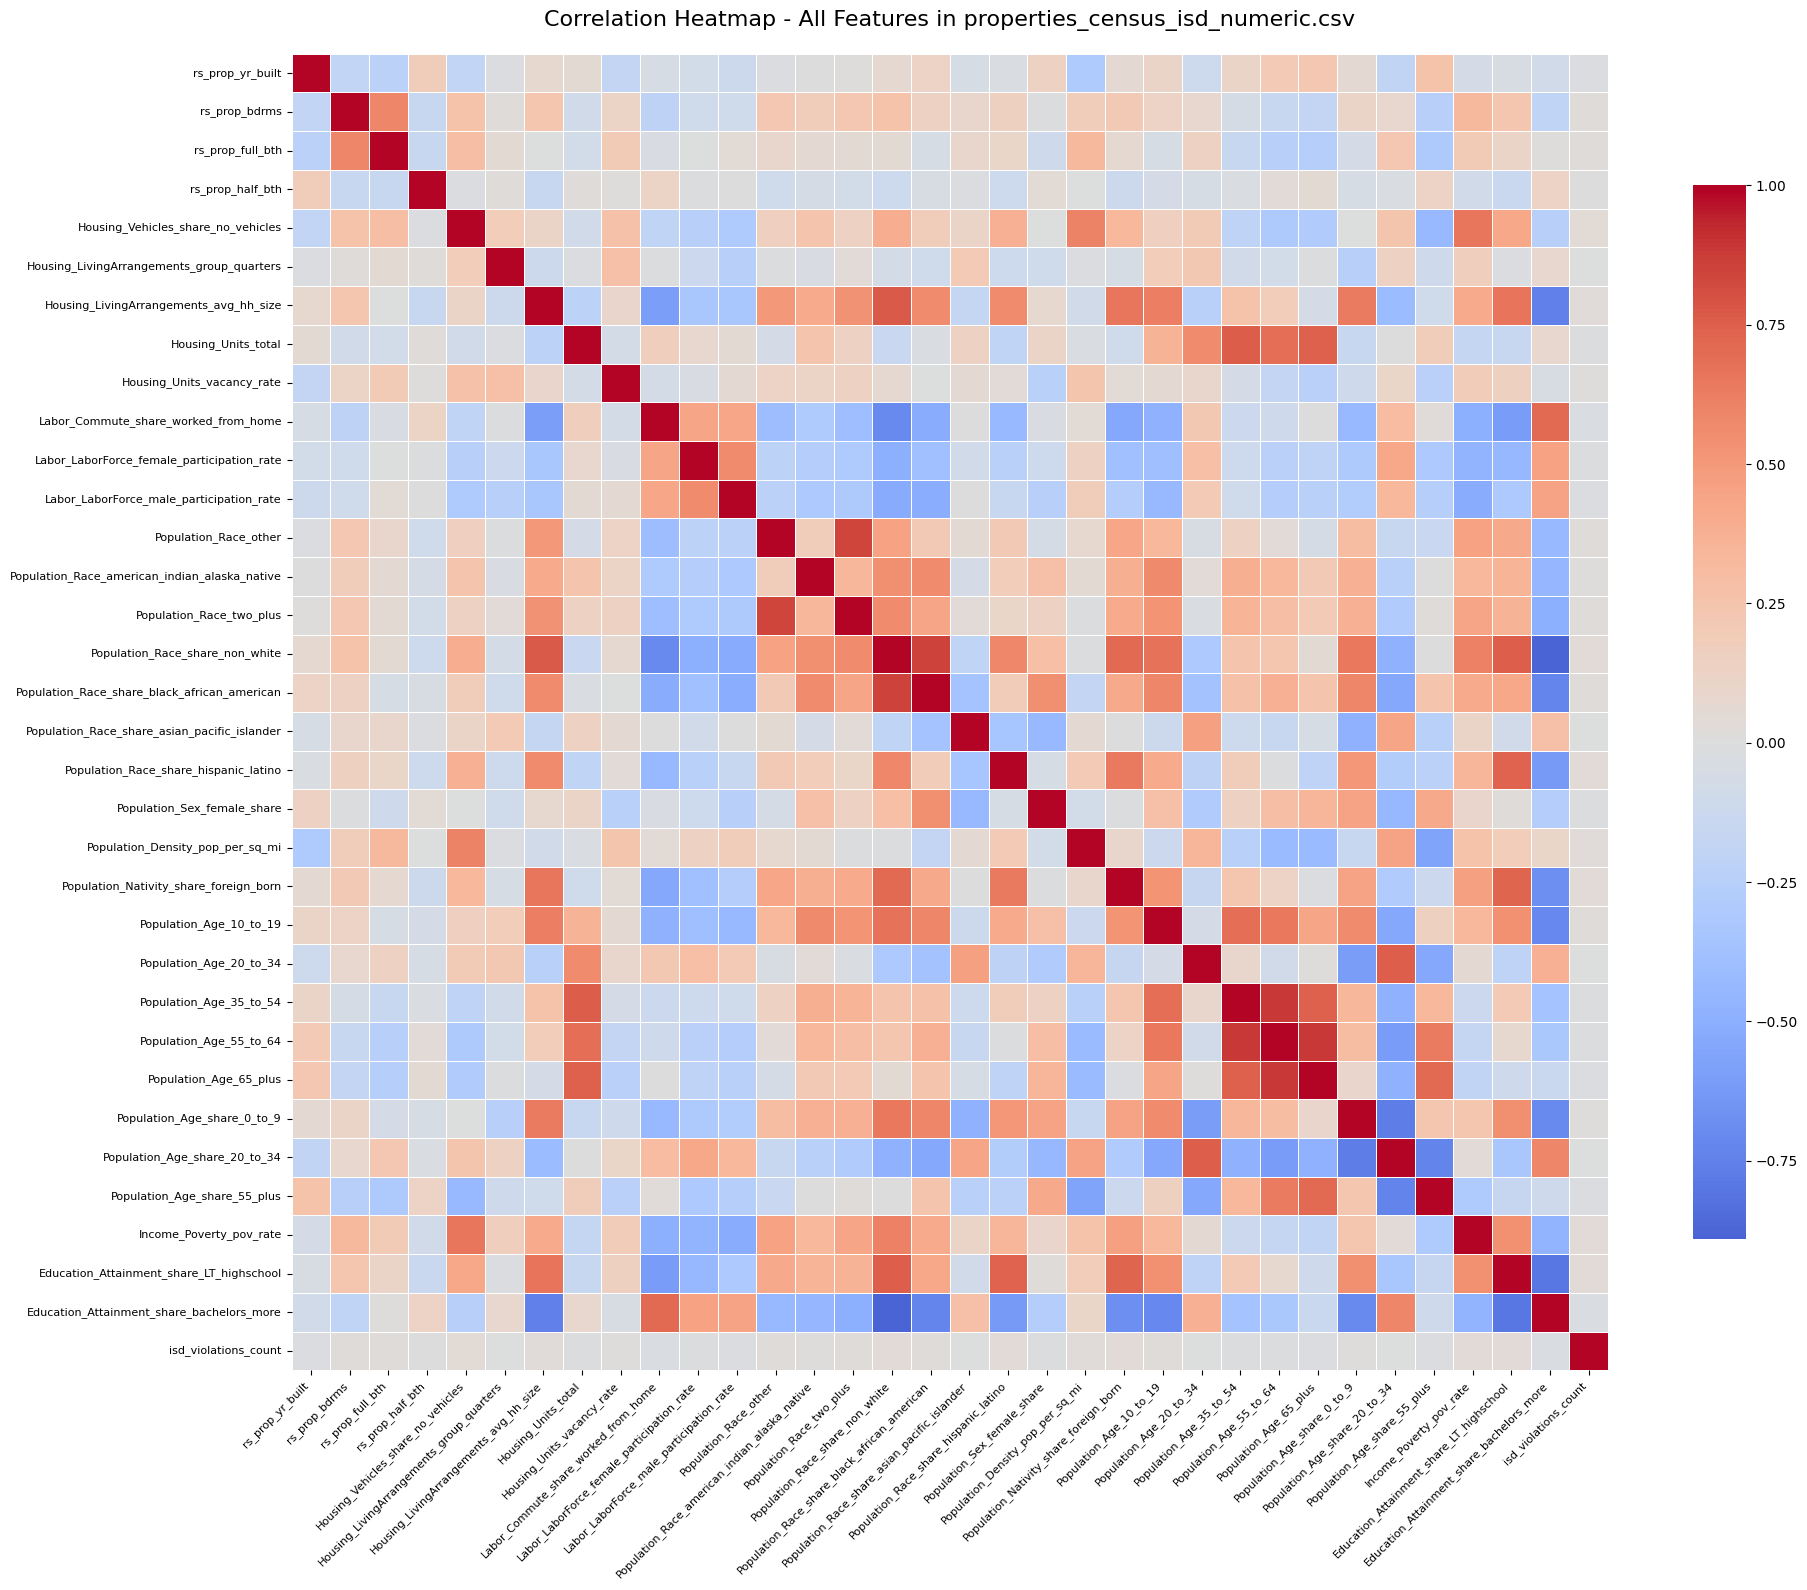

In [32]:
#correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

#remove columns from pci with high colinearity
pci2_df = pci_df.drop(columns=['Income_Poverty_tot_pov_stat_det', 'Housing_LivingArrangements_household_pop', 'Population_Sex_total_pop', 'Housing_Units_units_per_acre', 'Population_ChildrenByAge_5_to_17', 'Population_Age_0_to_9', 'Population_ChildrenByAge_under5'])
# Calculate correlation matrix
correlation_matrix = pci2_df.corr()

plt.figure(figsize=(20, 16))

# Create heatmap 
sns.heatmap(correlation_matrix, 
            annot=False,  # Remove numbers to avoid clutter
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title('Correlation Heatmap - All Features in properties_census_isd_numeric.csv', 
          fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()


In [27]:
#linear regression pci2df
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
# Prepare data
X = pci2_df.drop(columns=['isd_violations_count'])
y = pci2_df['isd_violations_count']
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Train linear regression model 
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)






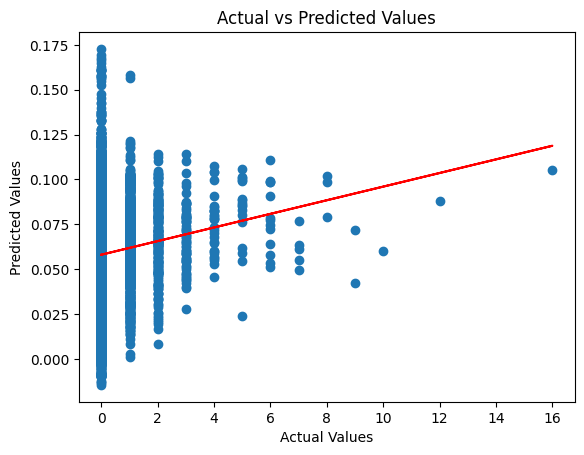

In [28]:
#plot 
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
# trend line
z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), color='red')

plt.show()

In [30]:
#eval
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")


Mean Squared Error: 0.15463925596668598
R^2 Score: 0.004326732063279715
